# Customer Personality Segmentation using Unsupervised Learning

## Objective
The goal of this project is to segment customers based on purchasing behavior using clustering algorithms.

### Algorithms Used
- K-Means Clustering
- PCA
- StandardScaler
- Elbow Method
- Silhouette Score

# Install Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Load Dataset

In [2]:
df = pd.read_csv("customer_personality_dataset.csv")

df

,TransactionID,CustomerID,CustomerTypeHidden,Product,Category,Quantity,UnitPrice,DiscountPercent,TotalAmount,PurchaseDate,PaymentMethod,WeekendPurchase,Country
0,1,1289,Premium,Headphones,Electronics,3,2875,10,7762.50,2025-05-16,Credit Card,False,Germany
1,2,1551,Bargain,Perfume,Beauty,3,190,55,256.50,2025-07-10,Net Banking,False,Germany
2,3,1955,Loyal,Sofa,Furniture,2,814,12,1432.64,2025-08-08,Net Banking,False,USA
3,4,1876,Bargain,Coffee Maker,Home,1,182,50,91.00,2025-12-23,Net Banking,False,Germany
4,5,1679,Loyal,Shoes,Fashion,4,137,9,498.68,2025-05-29,Cash on Delivery,False,UK
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11995,11996,1180,Inactive,Sofa,Furniture,2,398,5,756.20,2025-04-09,UPI,False,Canada
11996,11997,1800,Premium,Protein Powder,Fitness,3,624,4,1797.12,2024-11-23,Net Banking,True,Germany
11997,11998,1597,Inactive,Shoes,Fashion,1,309,13,268.83,2024-06-09,Debit Card,True,Canada
11998,11999,1716,Impulse,Headphones,Electronics,8,1355,0,10840.00,2025-05-07,Credit Card,False,India


# Dataset Information

In [3]:
df.columns

Index(['TransactionID', 'CustomerID', 'CustomerTypeHidden', 'Product',
       'Category', 'Quantity', 'UnitPrice', 'DiscountPercent', 'TotalAmount',
       'PurchaseDate', 'PaymentMethod', 'WeekendPurchase', 'Country'],
      dtype='object')

In [4]:
df.shape

(12000, 13)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   TransactionID       12000 non-null  int64  
 1   CustomerID          12000 non-null  int64  
 2   CustomerTypeHidden  12000 non-null  object 
 3   Product             12000 non-null  object 
 4   Category            12000 non-null  object 
 5   Quantity            12000 non-null  int64  
 6   UnitPrice           12000 non-null  int64  
 7   DiscountPercent     12000 non-null  int64  
 8   TotalAmount         12000 non-null  float64
 9   PurchaseDate        12000 non-null  object 
 10  PaymentMethod       12000 non-null  object 
 11  WeekendPurchase     12000 non-null  bool   
 12  Country             12000 non-null  object 
dtypes: bool(1), float64(1), int64(5), object(6)
memory usage: 1.1+ MB


# Missing Values

In [6]:
df.isnull().sum()

TransactionID         0
CustomerID            0
CustomerTypeHidden    0
Product               0
Category              0
Quantity              0
UnitPrice             0
DiscountPercent       0
TotalAmount           0
PurchaseDate          0
PaymentMethod         0
WeekendPurchase       0
Country               0
dtype: int64

# Remove Duplicates

In [7]:
df.drop_duplicates(inplace=True)

# Convert PurchaseDate to Datetime

In [8]:
df['PurchaseDate'] = pd.to_datetime(df['PurchaseDate'])

In [9]:
df['PurchaseMonth'] = df['PurchaseDate'].dt.month

In [10]:
df['PurchaseDay'] = df['PurchaseDate'].dt.day_name()

In [11]:
df['AvgSpendPerItem'] = df['TotalAmount'] / df['Quantity']

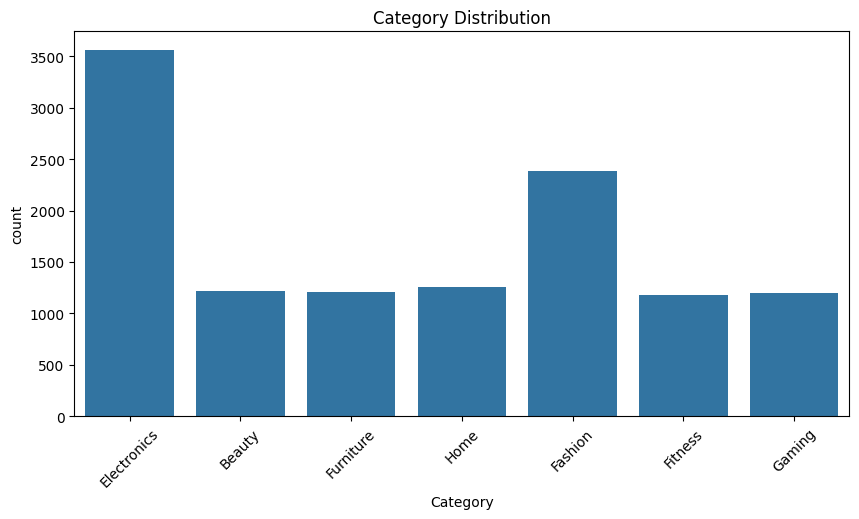

In [12]:
plt.figure(figsize=(10,5))

sns.countplot(x='Category', data=df)

plt.xticks(rotation=45)

plt.title("Category Distribution")

plt.show()

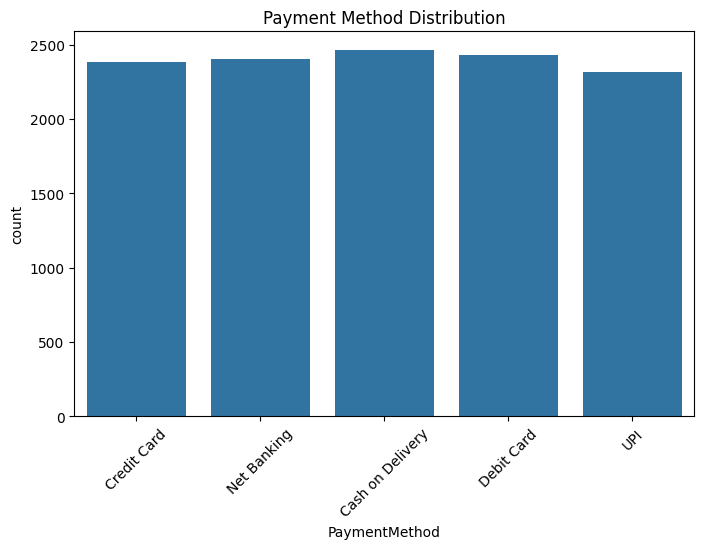

In [13]:
plt.figure(figsize=(8,5))

sns.countplot(x='PaymentMethod', data=df)

plt.xticks(rotation=45)

plt.title("Payment Method Distribution")

plt.show()

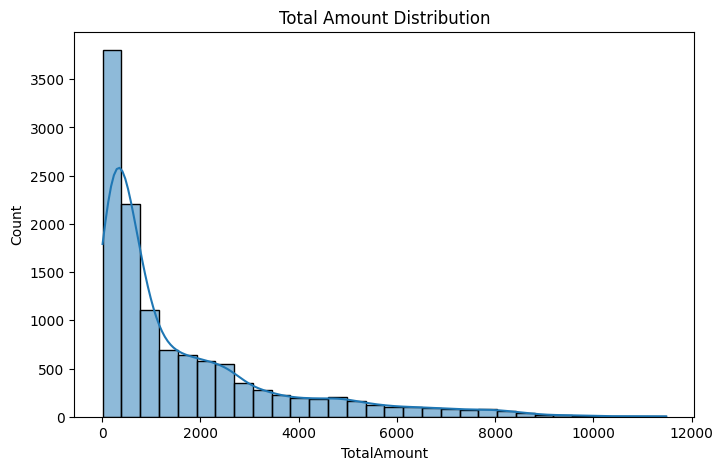

In [14]:
plt.figure(figsize=(8,5))

sns.histplot(df['TotalAmount'], bins=30, kde=True)

plt.title("Total Amount Distribution")

plt.show()

# Remove Unnecessary Columns

In [15]:
clustering_df = df.drop([
    'TransactionID',
    'CustomerID',
    'PurchaseDate',
    'CustomerTypeHidden'
], axis=1)

# Convert Categorical Data into Numeric

In [16]:
le = LabelEncoder()

categorical_cols = [
    'Product',
    'Category',
    'PaymentMethod',
    'Country',
    'PurchaseDay'
]

for col in categorical_cols:
    clustering_df[col] = le.fit_transform(clustering_df[col])

# Convert Boolean Values

In [17]:
clustering_df['WeekendPurchase'] = clustering_df['WeekendPurchase'].astype(int)

# Scale Features

In [18]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(clustering_df)

# Find Optimal Number of Clusters

In [19]:
wcss = []

for i in range(1, 11):
    
    kmeans = KMeans(n_clusters=i, random_state=42)
    
    kmeans.fit(scaled_data)
    
    wcss.append(kmeans.inertia_)

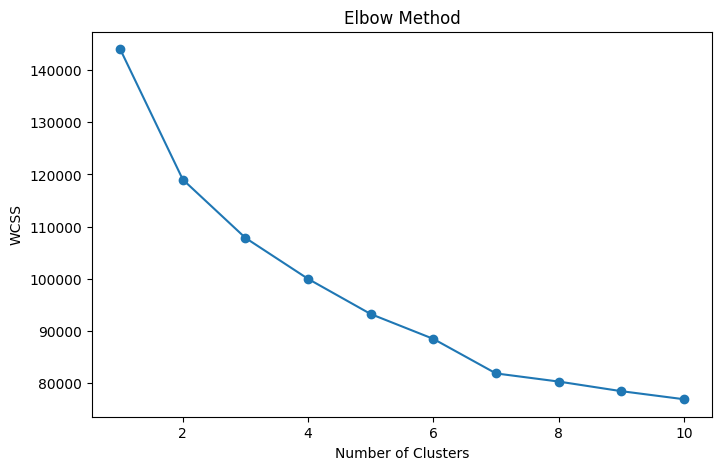

In [20]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.show()

# Apply Clustering

In [21]:
kmeans = KMeans(n_clusters=4, random_state=42)

clusters = kmeans.fit_predict(scaled_data)

# Add Cluster Column

In [22]:
clustering_df['Cluster'] = clusters

# Silhouette Score

In [23]:
score = silhouette_score(scaled_data, clusters)

print("Silhouette Score:", score)

Silhouette Score: 0.1394187299966646


# PCA for Visualization

In [24]:
pca = PCA(n_components=2)

pca_data = pca.fit_transform(scaled_data)

In [25]:
pca_df = pd.DataFrame(pca_data, columns=['PCA1', 'PCA2'])

pca_df['Cluster'] = clusters

# Plot Customer Segments

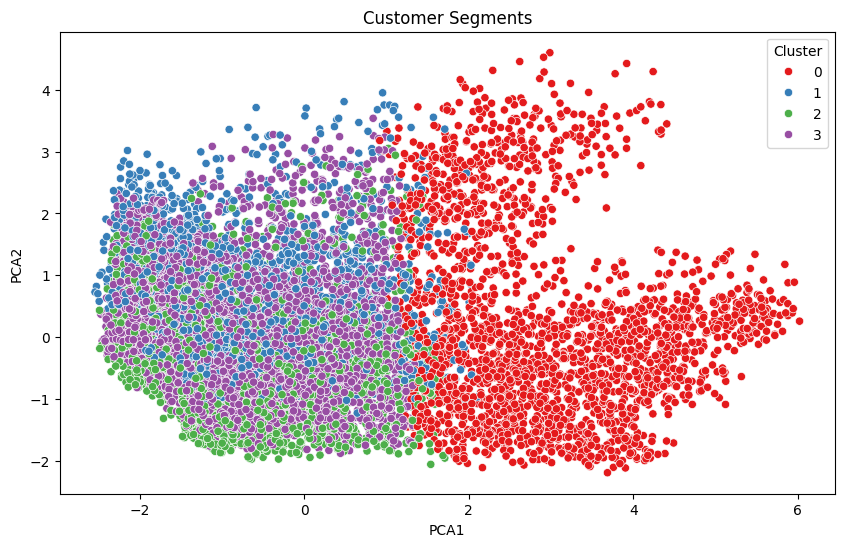

In [26]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='PCA1',
    y='PCA2',
    hue='Cluster',
    data=pca_df,
    palette='Set1'
)

plt.title("Customer Segments")

plt.show()

# Analyze Customer Groups

In [27]:
cluster_analysis = clustering_df.groupby('Cluster').mean()

print(cluster_analysis)

          Product  Category  Quantity    UnitPrice  DiscountPercent  \
Cluster                                                               
0        4.748339  2.350908  3.199380  1890.557820         7.247231   
1        0.476077  5.523923  2.611483   462.217225        17.970813   
2        5.483621  1.759327  2.535942   440.439035        17.925387   
3        5.483960  1.740605  2.597250   406.287443        18.391017   

         TotalAmount  PaymentMethod  WeekendPurchase   Country  PurchaseMonth  \
Cluster                                                                         
0        4746.464484       1.978290         0.245902  2.047851       6.529021   
1         997.222000       1.983254         0.281818  1.995694       6.514354   
2         924.294609       1.904459         1.000000  2.024113       6.402639   
3         867.863221       2.003300         0.000000  1.986984       6.564253   

         PurchaseDay  AvgSpendPerItem  
Cluster                                
0     

In [28]:
final_df = df.copy()

final_df['Cluster'] = clusters

In [29]:
final_df.to_csv("customer_segments_output.csv", index=False)

# Conclusion

In this project, we successfully performed Customer Personality Segmentation using Unsupervised Learning techniques.

We applied:

- Data Cleaning
- Feature Engineering
- Exploratory Data Analysis (EDA)
- Label Encoding
- Feature Scaling
- K-Means Clustering
- PCA Visualization
- Silhouette Score Evaluation

The K-Means algorithm grouped customers into multiple clusters based on their purchasing behavior and transaction patterns.

Using PCA visualization, we clearly observed different customer segments, where some clusters showed strong separation while others had overlapping behavior patterns.

## Key Findings

- Cluster 0 represented highly distinct customers with different purchasing behavior.
- Other clusters represented medium, budget, and mixed-behavior customers.
- Customer segmentation helps businesses better understand customer preferences and spending habits.

## Business Benefits

This project can help companies:

- Improve personalized marketing
- Create targeted advertisements
- Increase customer retention
- Build recommendation systems
- Identify premium customers
- Improve pricing strategies

## Final Outcome

The project successfully discovered hidden customer groups without using labeled data, demonstrating the power of unsupervised learning techniques in solving real-world business problems.

Overall, this project provides valuable insights into customer behavior and helps organizations make data-driven decisions.